# Métodos de agrupamiento

# Agrupamiento por mezclas gaussianas

In [1]:
import pandas as pd
from google.colab import files

# Métodos de agrupamiento
# Algoritmos de agrupamiento por k-medias.

# Cargue del conjunto de datos
uploaded = files.upload()
datos = pd.read_excel("Fish.xlsx")

print(datos.head())
print(datos.shape)

Saving Fish.xlsx to Fish.xlsx
  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
3   Bream   363.0     26.3     29.0     33.5  12.7300  4.4555
4   Bream   430.0     26.5     29.0     34.0  12.4440  5.1340
(159, 7)


In [2]:
# Variable Species, solo para comparar
species = datos["Species"].astype("category")

species.head()

,Species
0,Bream
1,Bream
2,Bream
3,Bream
4,Bream


In [3]:
# Variables numéricas estandarizadas
datos = datos.loc[:, "Weight":"Width"].copy()
datos = (datos - datos.mean()) / datos.std(ddof=1)

datos.head()

,Weight,Length1,Length2,Length3,Height,Width
0,-0.436692,-0.304825,-0.281414,-0.105686,0.594700,-0.235784
1,-0.302606,-0.224797,-0.197430,-0.002329,0.818674,-0.066369
2,-0.162933,-0.234801,-0.178767,-0.010942,0.794830,0.165271
3,-0.098683,0.005285,0.054522,0.195772,0.877001,0.022550
4,0.088479,0.025292,0.054522,0.238837,0.810275,0.425028


In [4]:
from sklearn.mixture import GaussianMixture

# Modelo de mezcla gaussiana
modelos = []

for G in range(1, 11):
    for cov in ["full", "tied", "diag", "spherical"]:
        mod = GaussianMixture(
            n_components=G,
            covariance_type=cov,
            random_state=123
        ).fit(datos)

        modelos.append({
            "G": G,
            "covariance_type": cov,
            "bic": mod.bic(datos),
            "modelo": mod
        })

res_gmm = pd.DataFrame(modelos)

mejor = res_gmm.loc[res_gmm["bic"].idxmin()]

ag_gmm = mejor["modelo"]

mejor[["G", "covariance_type", "bic"]]

,24
G,7
covariance_type,full
bic,-783.931317


In [5]:
# Grupos asignados
ag_gmm.n_components

grupos = ag_gmm.predict(datos) + 1

pd.Series(grupos).value_counts().sort_index()

,count
1,12
2,21
3,41
4,21
5,5
6,31
7,28


In [6]:
# Probabilidades de pertenencia
prob = pd.DataFrame(
    ag_gmm.predict_proba(datos),
    columns=[f"Grupo {j}" for j in range(1, ag_gmm.n_components + 1)]
)

prob.round(5)

,Grupo 1,Grupo 2,Grupo 3,Grupo 4,Grupo 5,Grupo 6,Grupo 7
0,0.0,0.0,0.0,0.0,0.0,0.99761,0.00239
1,0.0,0.0,0.0,0.0,0.0,0.90317,0.09683
2,0.0,0.0,0.0,0.0,0.0,1.00000,0.00000
3,0.0,0.0,0.0,0.0,0.0,0.99879,0.00121
4,0.0,0.0,0.0,0.0,0.0,0.99717,0.00283
...,...,...,...,...,...,...,...
154,0.0,1.0,0.0,0.0,0.0,0.00000,0.00000
155,0.0,1.0,0.0,0.0,0.0,0.00000,0.00000
156,0.0,1.0,0.0,0.0,0.0,0.00000,0.00000
157,0.0,1.0,0.0,0.0,0.0,0.00000,0.00000


In [7]:
# Comparando con Species
pd.crosstab(
    pd.Series(grupos, name="grupos"),
    pd.Series(species, name="species")
)

species,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
grupos,,,,,,,
1,0,0,0,12,0,0,0
2,0,2,4,0,1,14,0
3,0,7,21,0,13,0,0
4,0,0,18,0,0,0,3
5,0,0,0,5,0,0,0
6,7,2,13,0,6,0,3
7,28,0,0,0,0,0,0


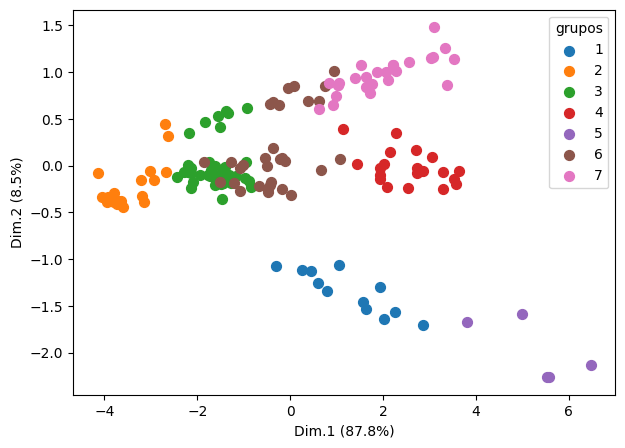

In [11]:
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

# Gráficos
acp = PCA(n_components=2)
coord = acp.fit_transform(datos)

plot_gmm = pd.DataFrame({
    "Dim.1": coord[:, 0],
    "Dim.2": coord[:, 1],
    "grupos": grupos
})

plt.figure(figsize=(7, 5))
for g in sorted(plot_gmm["grupos"].unique()):
    temp = plot_gmm[plot_gmm["grupos"] == g]
    plt.scatter(temp["Dim.1"], temp["Dim.2"], label=str(g), s=50)

plt.xlabel(f"Dim.1 ({acp.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Dim.2 ({acp.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="grupos")
plt.show()

In [13]:
# Validación

res_gmm[["G", "covariance_type", "bic"]].sort_values("bic").head(10)

ag_gmm.bic(datos) # debe ser minimizado en sklearn

np.float64(-783.9313167724573)

In [14]:
import numpy as np
from sklearn.metrics import pairwise_distances, silhouette_score, calinski_harabasz_score

# Distancia
D = pairwise_distances(datos, metric="euclidean") # datos debe estar estandarizado
np.fill_diagonal(D, 0)

val_avg_silwidth = silhouette_score(D, grupos, metric="precomputed")

clusters = np.unique(grupos)

diametros = []
separaciones = []

for g in clusters:
    idx = grupos == g
    diametros.append(D[np.ix_(idx, idx)].max())

for i, g1 in enumerate(clusters):
    for g2 in clusters[(i + 1):]:
        idx1 = grupos == g1
        idx2 = grupos == g2
        separaciones.append(D[np.ix_(idx1, idx2)].min())

val_dunn = min(separaciones) / max(diametros)

val_ch = calinski_harabasz_score(datos, grupos)

print(val_avg_silwidth) # silueta promedio, maximizar
print(val_dunn)         # índice de Dunn, maximizar
print(val_ch)           # Calinski-Harabasz, maximizar

0.40094494293440813
0.03835226415006327
241.69611705923427
